# Lab 3: Time of Flight Sensors

This notebook covers all data-collection and analysis tasks for Lab 3:
1. Connect to Artemis via BLE
2. I2C address discussion
3. Characterise ToF sensor (range, accuracy, repeatability, timing)
4. Two ToF sensors working simultaneously
5. Non-blocking loop speed test
6. Record time-stamped ToF + IMU data over Bluetooth
7. Plot: Distance vs Time (both sensors)
8. Plot: Angle vs Time (IMU complementary filter)

## 1. Setup and Imports

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 12

## 2. Connect to Artemis via BLE

In [2]:
ble = get_ble_controller()
ble.connect()
print("Connected!")

2026-03-08 22:03:16,218 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:31:25:23:64
2026-03-08 22:03:16,218 | INFO     |: Scanning for device with address: c0:81:31:25:23:64, service UUID: d1e59283-ea64-46d2-9619-feda9179e362
2026-03-08 22:03:26,332 | INFO     |: Found 1 device(s) advertising service d1e59283-ea64-46d2-9619-feda9179e362
2026-03-08 22:03:26,333 | INFO     |: Selecting device: CA4CC09F-B046-D9C9-C03F-F04C7AD18338 (name: Artemis BLE)
2026-03-08 22:03:27,301 | INFO     |: Connected to c0:81:31:25:23:64
Connected!


In [3]:
# Verify connection
ble.send_command(CMD.PING, "")
response = ble.receive_string(ble.uuid['RX_STRING'])
print(f"Response: {response}")

Response: PONG


## 3. I2C Address

The VL53L1X default I2C address is **0x29** (7-bit).  
Because both sensors share the same hardwired address we use the **XSHUT pin approach**:
1. Pull both XSHUT LOW → both sensors powered off.
2. Raise XSHUT_1 → sensor 1 boots at 0x29.
3. Call `sensor1.setI2CAddress(0x30)` → sensor 1 now answers at 0x30.
4. Raise XSHUT_2 → sensor 2 boots at 0x29.
5. Both sensors are now individually addressable on the same I²C bus.

The alternative (toggling XSHUT at runtime) works but forces serial access and halves the effective measurement rate.

## 4. Helper Functions

In [4]:
# ── Global notification buffer ──────────────────────────────────────────────
data_buffer = []

def notification_handler(sender, data):
    """Append every incoming BLE string to the buffer."""
    global data_buffer
    data_buffer.append(data.decode('utf-8'))


# ── Single ToF reading ───────────────────────────────────────────────────────
def get_tof_reading():
    """Request one distance reading from both sensors.

    Returns:
        (dist1_mm, dist2_mm) or (None, None) on error.
    """
    ble.send_command(CMD.GET_TOF_DATA, "")
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    if resp == "TOF_ERROR" or resp is None:
        print("ToF sensor not available")
        return None, None
    parts = resp.split('|')
    if len(parts) == 2:
        return int(parts[0]), int(parts[1])
    return None, None


# ── Parse helpers ────────────────────────────────────────────────────────────
def parse_tof_data(buffer):
    """Extract ToF samples from notification buffer.

    Expected format per line: "T|timestamp_ms|dist1_mm|dist2_mm"
    Returns DataFrame with columns: time_ms, time_s, dist1, dist2
    """
    rows = []
    for line in buffer:
        if not line.startswith('T|'):
            continue
        parts = line.split('|')
        if len(parts) == 4:
            try:
                rows.append([int(parts[1]), int(parts[2]), int(parts[3])])
            except ValueError:
                pass
    df = pd.DataFrame(rows, columns=['time_ms', 'dist1', 'dist2'])
    if len(df) > 0:
        df['time_s'] = (df['time_ms'] - df['time_ms'].iloc[0]) / 1000.0
    return df


def parse_imu_data(buffer):
    """Extract IMU samples from notification buffer.

    Expected format: "timestamp|pitch_a|roll_a|pitch_comp|roll_comp"
    Returns DataFrame with columns: time_ms, time_s, pitch_a, roll_a, pitch_comp, roll_comp
    """
    rows = []
    for line in buffer:
        if line.startswith('T|') or line.startswith('IMU_') or line.startswith('TOF'):
            continue
        parts = line.split('|')
        if len(parts) == 5:
            try:
                rows.append([float(x) for x in parts])
            except ValueError:
                pass
    df = pd.DataFrame(rows, columns=['time_ms', 'pitch_a', 'roll_a', 'pitch_comp', 'roll_comp'])
    if len(df) > 0:
        df['time_s'] = (df['time_ms'] - df['time_ms'].iloc[0]) / 1000.0
    return df


print("Helper functions defined.")

Helper functions defined.


---
## 5. ToF Sensor Characterisation (Task 7)

### Distance Mode Discussion
| Mode | Max Range | Timing Budget | Notes |
|------|-----------|---------------|-------|
| **Short** | ~1.3 m | ≤ 20 ms | Less sensitive to ambient light; reliable up to 1.3 m |
| **Long** | ~4 m | ≥ 33 ms | Effective up to 4 m; more susceptible to ambient light |

Both modes are tested over **100 mm – 1500 mm** using **256 readings per distance** to demonstrate repeatability (the datasheet benchmarks use 32 readings; 256 is used here to match the number of IMU readings taken).

In [5]:
# Distance test points: every 400 mm
true_distances_mm = [100, 500, 900, 1300, 1700]
N_SAMPLES = 50

print(f"Test distances: {true_distances_mm} mm")
print(f"Readings per point: {N_SAMPLES}")

Test distances: [100, 500, 900, 1300, 1700] mm
Readings per point: 50


### 5a. Collect data — single-shot GET_TOF_DATA (both sensors, Short & Long)

Each distance point uses `N_SAMPLES` individual `GET_TOF_DATA` calls.  
Results printed in **mm** and **inch**.

In [6]:
def collect_singleshot(sensor=1, n=N_SAMPLES):
    """Collect n single GET_TOF_DATA readings for the given sensor (1 or 2).
    Returns list of valid distances in mm.
    """
    col_idx = 0 if sensor == 1 else 1
    vals = []
    for _ in range(n):
        ble.send_command(CMD.GET_TOF_DATA, "")
        time.sleep(0.15)   # ~100 ms measurement period + BLE margin
        raw = ble.receive_string(ble.uuid['RX_STRING'])
        if raw and '|' in raw:
            parts = raw.split('|')
            try:
                d = int(parts[col_idx])
                if d > 0:
                    vals.append(d)
            except (ValueError, IndexError):
                pass
    if len(vals) < n:
        print(f"    ⚠ only {len(vals)} valid samples (expected {n})")
    return vals


def run_characterisation_singleshot(sensor, mode_name, mode_cmd):
    """Set distance mode then collect N_SAMPLES single-shot readings per distance."""
    ble.send_command(CMD.SET_TOF_MODE, str(mode_cmd))
    time.sleep(2.0)
    print(f"[Sensor {sensor} | {mode_name}] Mode set\n")

    hdr = f"{'True mm':>8}  {'True in':>8}  {'Mean mm':>8}  {'σ mm':>6}  {'Err mm':>8}  n"
    print(hdr)
    print("-" * len(hdr))

    means, stds, all_samples = [], [], []
    for true_d in true_distances_mm:
        true_in = true_d / 25.4
        input(f"  → Sensor {sensor} face to {true_d} mm ({true_in:.2f} in), press Enter...")
        s = collect_singleshot(sensor=sensor, n=N_SAMPLES)
        if len(s) == 0:
            print(f"  {true_d:>8}  {true_in:>8.2f}  {'NO DATA':>8}")
            means.append(float('nan'))
            stds.append(float('nan'))
            all_samples.append([])
            continue
        m   = np.mean(s)
        sd  = np.std(s)
        err = m - true_d
        means.append(m)
        stds.append(sd)
        all_samples.append(s)
        print(f"  {true_d:>8}  {true_in:>8.2f}  {m:>8.1f}  {sd:>6.1f}  {err:>+8.1f}  {len(s)}")

    return means, stds, all_samples


# ── Sensor 1 ─────────────────────────────────────────────────────────────────
print("═══ SENSOR 1 | SHORT MODE ═══")
s1_short_means, s1_short_stds, s1_short_all = run_characterisation_singleshot(1, "SHORT", 0)

print("\n═══ SENSOR 1 | LONG MODE ═══")
s1_long_means, s1_long_stds, s1_long_all = run_characterisation_singleshot(1, "LONG", 1)

# ── Sensor 2 ─────────────────────────────────────────────────────────────────
print("\n═══ SENSOR 2 | SHORT MODE ═══")
s2_short_means, s2_short_stds, s2_short_all = run_characterisation_singleshot(2, "SHORT", 0)

print("\n═══ SENSOR 2 | LONG MODE ═══")
s2_long_means, s2_long_stds, s2_long_all = run_characterisation_singleshot(2, "LONG", 1)

print("\nAll collection complete.")

═══ SENSOR 1 | SHORT MODE ═══
[Sensor 1 | SHORT] Mode set

 True mm   True in   Mean mm    σ mm    Err mm  n
-------------------------------------------------
       100      3.94      87.8     1.1     -12.2  50
       500     19.69     483.3     1.0     -16.7  50
       900     35.43     869.6     1.5     -30.4  50
      1300     51.18    1247.9     2.2     -52.1  50
      1700     66.93    2256.6     7.4    +556.6  50

═══ SENSOR 1 | LONG MODE ═══
[Sensor 1 | LONG] Mode set

 True mm   True in   Mean mm    σ mm    Err mm  n
-------------------------------------------------
       100      3.94      87.3     1.2     -12.7  50
       500     19.69     480.8     1.1     -19.2  50
       900     35.43     865.5     1.3     -34.5  50
      1300     51.18    1271.0     2.0     -29.0  50
      1700     66.93    2085.8     6.7    +385.8  50

═══ SENSOR 2 | SHORT MODE ═══
[Sensor 2 | SHORT] Mode set

 True mm   True in   Mean mm    σ mm    Err mm  n
-------------------------------------------

── Sensor 1 ────────────────────────────────────────────────────


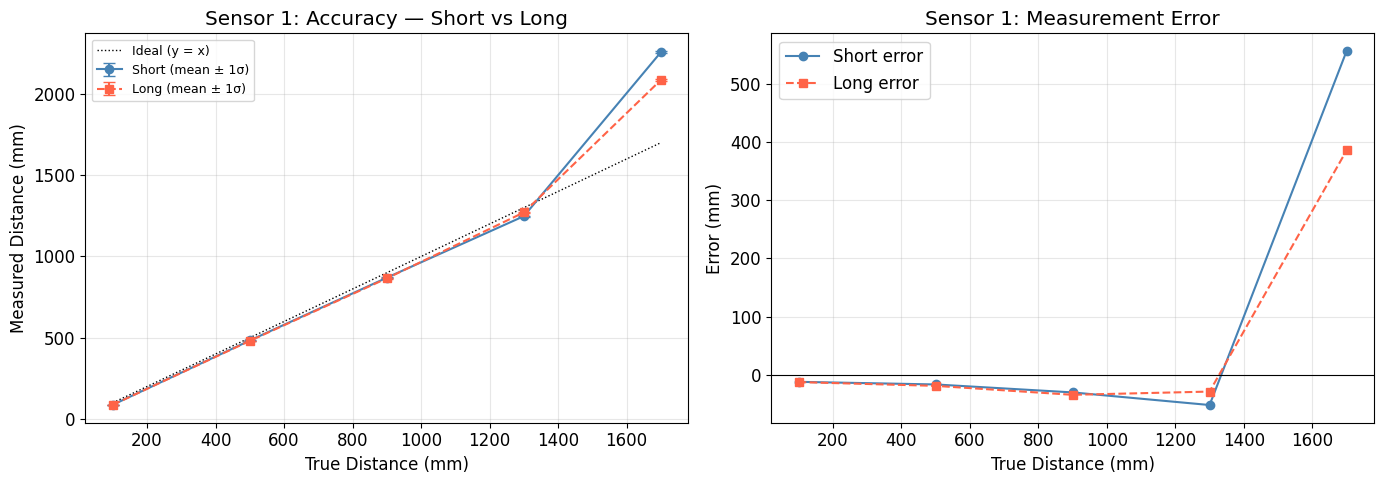

  Short — MAE=133.6 mm
  Long  — MAE=96.2 mm

── Sensor 2 ────────────────────────────────────────────────────


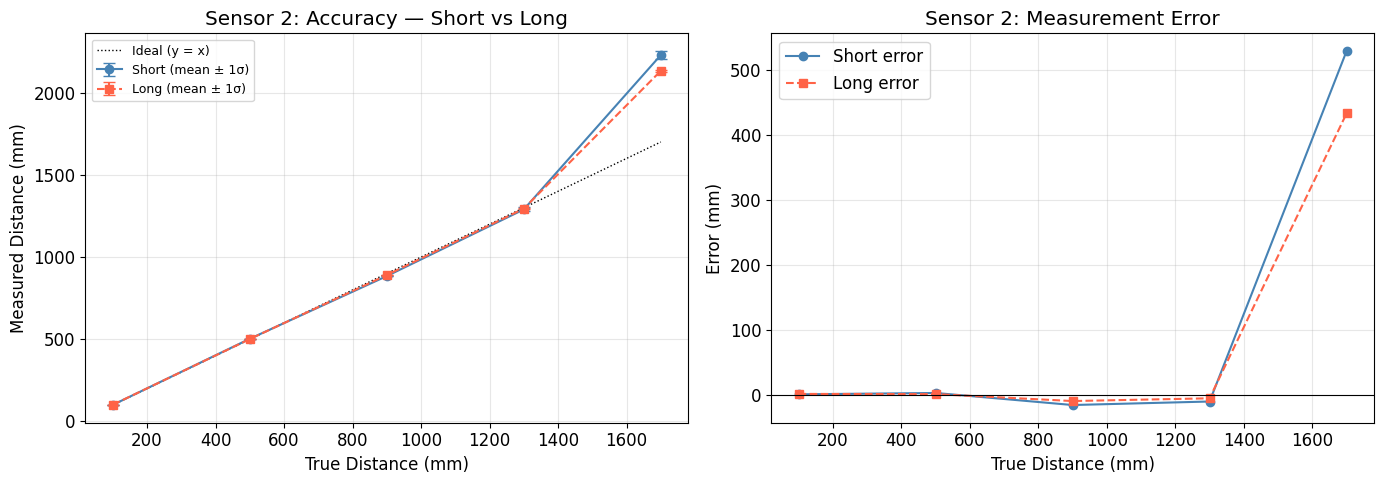

  Short — MAE=111.7 mm
  Long  — MAE=90.1 mm


In [12]:
def plot_accuracy(sensor_id, sh_means, sh_stds, lg_means, lg_stds, save_name):
    """Accuracy plot for one sensor: measured points connected by straight lines."""
    true = np.array(true_distances_mm, dtype=float)
    sh_m = np.array(sh_means, dtype=float)
    lg_m = np.array(lg_means, dtype=float)

    sh_ok = ~np.isnan(sh_m)
    lg_ok = ~np.isnan(lg_m)

    sh_err = sh_m - true
    lg_err = lg_m - true

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: measured vs true, lines connecting data points ─────────────────
    ax = axes[0]
    ax.errorbar(true[sh_ok], sh_m[sh_ok], yerr=np.array(sh_stds)[sh_ok],
                fmt='o-', capsize=4, color='steelblue', label='Short (mean ± 1σ)', zorder=3)
    ax.errorbar(true[lg_ok], lg_m[lg_ok], yerr=np.array(lg_stds)[lg_ok],
                fmt='s--', capsize=4, color='tomato', label='Long (mean ± 1σ)', zorder=3)
    ax.plot(true, true, 'k:', linewidth=1, label='Ideal (y = x)')
    ax.set_xlabel('True Distance (mm)')
    ax.set_ylabel('Measured Distance (mm)')
    ax.set_title(f'Sensor {sensor_id}: Accuracy — Short vs Long')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Right: residual error ─────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.plot(true[sh_ok], sh_err[sh_ok], 'o-', color='steelblue', label='Short error')
    ax2.plot(true[lg_ok], lg_err[lg_ok], 's--', color='tomato',   label='Long error')
    ax2.axhline(0, color='k', linewidth=0.8)
    ax2.set_xlabel('True Distance (mm)')
    ax2.set_ylabel('Error (mm)')
    ax2.set_title(f'Sensor {sensor_id}: Measurement Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  Short — MAE={np.nanmean(np.abs(sh_err)):.1f} mm")
    print(f"  Long  — MAE={np.nanmean(np.abs(lg_err)):.1f} mm")


print("── Sensor 1 ────────────────────────────────────────────────────")
plot_accuracy(1, s1_short_means, s1_short_stds, s1_long_means, s1_long_stds,
              'tof_accuracy_sensor1.png')

print("\n── Sensor 2 ────────────────────────────────────────────────────")
plot_accuracy(2, s2_short_means, s2_short_stds, s2_long_means, s2_long_stds,
              'tof_accuracy_sensor2.png')

### 5b. Repeatability — distribution of 256 readings at select distances

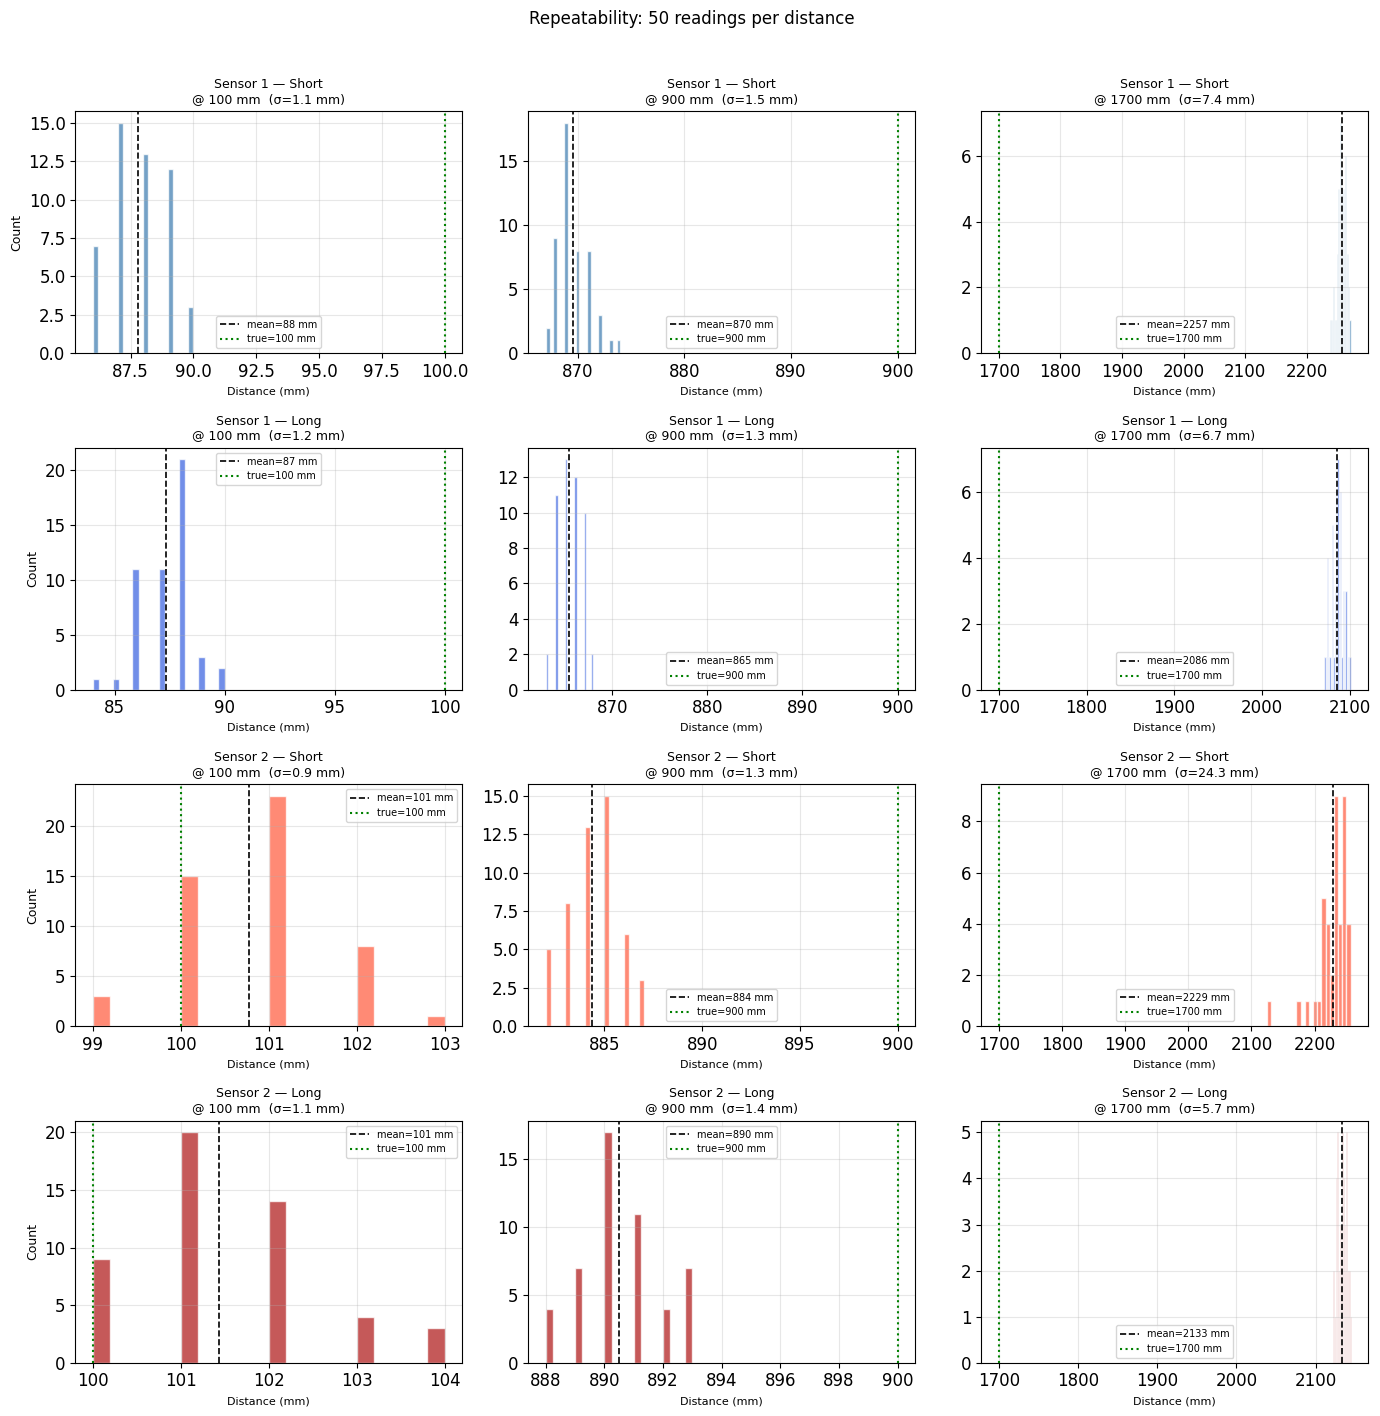

In [13]:
# Repeatability histograms: 3 distances × 2 sensors × 2 modes
plot_indices = [0, 2, 4]   # 100 mm, 900 mm, 1700 mm

datasets = [
    (s1_short_all, 'Sensor 1 — Short', 'steelblue'),
    (s1_long_all,  'Sensor 1 — Long',  'royalblue'),
    (s2_short_all, 'Sensor 2 — Short', 'tomato'),
    (s2_long_all,  'Sensor 2 — Long',  'firebrick'),
]

fig, axes = plt.subplots(4, 3, figsize=(14, 14))

for row, (all_samples, label, color) in enumerate(datasets):
    for col, idx in enumerate(plot_indices):
        d = true_distances_mm[idx]
        s = all_samples[idx]
        ax = axes[row][col]
        if len(s) == 0:
            ax.text(0.5, 0.5, 'NO DATA', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{label}\n@ {d} mm', fontsize=9)
            continue
        ax.hist(s, bins=20, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(np.mean(s), color='k', linestyle='--', linewidth=1.2,
                   label=f'mean={np.mean(s):.0f} mm')
        ax.axvline(d, color='green', linestyle=':', linewidth=1.5,
                   label=f'true={d} mm')
        ax.set_title(f'{label}\n@ {d} mm  (σ={np.std(s):.1f} mm)', fontsize=9)
        ax.set_xlabel('Distance (mm)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    axes[row][0].set_ylabel('Count', fontsize=9)

plt.suptitle(f'Repeatability: {N_SAMPLES} readings per distance', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('tof_repeatability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Two ToF Sensors Simultaneously (Task 8)

Verify that both sensors return valid, independent readings.

In [14]:
# ── Sensor 1 quick debug ─────────────────────────────────────────────────────
# Sends GET_TOF_DATA 5 times and prints the raw BLE response.
# Expected: "dist1|dist2"  e.g. "342|891"
# If sensor 1 is dead you will see "-1|xxx" or "TOF_ERROR".

print("Raw GET_TOF_DATA responses (5 samples):\n")
for i in range(5):
    ble.send_command(CMD.GET_TOF_DATA, "")
    time.sleep(0.2)
    raw = ble.receive_string(ble.uuid['RX_STRING'])
    print(f"  [{i+1}] raw = {repr(raw)}")
    if raw and '|' in raw:
        parts = raw.split('|')
        d1, d2 = parts[0], parts[1]
        print(f"       → sensor1={d1} mm,  sensor2={d2} mm")
    time.sleep(0.1)

Raw GET_TOF_DATA responses (5 samples):

  [1] raw = '615|555'
       → sensor1=615 mm,  sensor2=555 mm
  [2] raw = '612|555'
       → sensor1=612 mm,  sensor2=555 mm
  [3] raw = '617|556'
       → sensor1=617 mm,  sensor2=556 mm
  [4] raw = '613|558'
       → sensor1=613 mm,  sensor2=558 mm
  [5] raw = '614|556'
       → sensor1=614 mm,  sensor2=556 mm


In [15]:
print("Reading both sensors simultaneously (10 samples)...")
print(f"{'#':>3}  {'Sensor 1 (mm)':>14}  {'Sensor 2 (mm)':>14}")
print("-" * 38)

for i in range(10):
    d1, d2 = get_tof_reading()
    print(f"{i+1:>3}  {d1 if d1 is not None else 'ERR':>14}  {d2 if d2 is not None else 'ERR':>14}")
    time.sleep(0.1)

print("\nBoth sensors are active and returning independent readings.")

Reading both sensors simultaneously (10 samples)...
  #   Sensor 1 (mm)   Sensor 2 (mm)
--------------------------------------
  1             610             556
  2             612             556
  3             614             557
  4             617             555
  5             617             558
  6             612             555
  7             611             559
  8             612             556
  9             617             558
 10             618             555

Both sensors are active and returning independent readings.


---
## 7. Non-Blocking Speed Test (Task 9)

On the Artemis, the loop runs as fast as possible.  
ToF data is only appended when `checkForDataReady()` returns `true`.

We demonstrate this by recording for 5 seconds and computing:
- IMU sample rate (runs every loop iteration, limited by sensor ODR ~100 Hz)
- ToF sample rate (limited by ranging time ~33 ms for Long mode → ~30 Hz)

In [16]:
# Short recording to measure loop rates
data_buffer = []

ble.start_notify(ble.uuid['RX_STRING'], notification_handler)

ble.send_command(CMD.START_TOF_RECORDING, "")
time.sleep(0.3)

print("Recording for 3 seconds (keep sensors still)...")
time.sleep(3)

ble.send_command(CMD.STOP_TOF_RECORDING, "")
time.sleep(0.3)

# Retrieve ToF data
ble.send_command(CMD.SEND_TOF_DATA, "")
time.sleep(5)  # allow transfer

# Retrieve IMU data
ble.send_command(CMD.SEND_IMU_DATA, "")
time.sleep(15)  # allow IMU transfer

ble.stop_notify(ble.uuid['RX_STRING'])

df_tof_speed = parse_tof_data(data_buffer)
df_imu_speed = parse_imu_data(data_buffer)

print(f"ToF samples: {len(df_tof_speed)}")
print(f"IMU samples: {len(df_imu_speed)}")

if len(df_tof_speed) > 1:
    tof_dur = df_tof_speed['time_s'].iloc[-1]
    print(f"ToF rate: {len(df_tof_speed)/tof_dur:.1f} Hz  (limiting factor: sensor ranging time ~33 ms)")

if len(df_imu_speed) > 1:
    imu_dur = df_imu_speed['time_s'].iloc[-1]
    print(f"IMU rate: {len(df_imu_speed)/imu_dur:.1f} Hz")

Recording for 3 seconds (keep sensors still)...
ToF samples: 33
IMU samples: 207
ToF rate: 10.3 Hz  (limiting factor: sensor ranging time ~33 ms)
IMU rate: 62.1 Hz


---
## 8. Combined ToF + IMU Recording (Task 10)

Record ≥ 5 seconds of time-stamped data from both ToF sensors and the IMU.

In [17]:
def collect_combined_data(duration_s=6):
    """Record ToF + IMU data for duration_s seconds and return both DataFrames."""
    global data_buffer
    data_buffer = []

    ble.start_notify(ble.uuid['RX_STRING'], notification_handler)

    ble.send_command(CMD.START_TOF_RECORDING, "")
    time.sleep(0.3)
    print(f"Recording {duration_s} s — move sensors if you like...")
    time.sleep(duration_s)

    ble.send_command(CMD.STOP_TOF_RECORDING, "")
    time.sleep(0.3)

    # Fetch ToF data
    print("Transferring ToF data...")
    ble.send_command(CMD.SEND_TOF_DATA, "")
    time.sleep(6)

    # Fetch IMU data (reuses existing SEND_IMU_DATA command)
    print("Transferring IMU data...")
    ble.send_command(CMD.SEND_IMU_DATA, "")
    time.sleep(20)

    ble.stop_notify(ble.uuid['RX_STRING'])

    df_tof = parse_tof_data(data_buffer)
    df_imu = parse_imu_data(data_buffer)

    print(f"ToF samples: {len(df_tof)}")
    print(f"IMU samples: {len(df_imu)}")
    return df_tof, df_imu


df_tof, df_imu = collect_combined_data(duration_s=6)

Recording 6 s — move sensors if you like...
Transferring ToF data...
Transferring IMU data...
ToF samples: 63
IMU samples: 388


In [18]:
# Validate coverage
if len(df_tof) > 1:
    tof_dur = df_tof['time_s'].iloc[-1]
    tof_rate = len(df_tof) / tof_dur if tof_dur > 0 else 0
    print(f"ToF  — {len(df_tof)} samples, {tof_dur:.2f} s, {tof_rate:.1f} Hz")

if len(df_imu) > 1:
    imu_dur = df_imu['time_s'].iloc[-1]
    imu_rate = len(df_imu) / imu_dur if imu_dur > 0 else 0
    print(f"IMU  — {len(df_imu)} samples, {imu_dur:.2f} s, {imu_rate:.1f} Hz")

    if imu_dur >= 5:
        print("✓ 5+ seconds of IMU data captured!")

ToF  — 63 samples, 6.20 s, 10.2 Hz
IMU  — 388 samples, 6.32 s, 61.4 Hz
✓ 5+ seconds of IMU data captured!


---
## 9. Plot: Distance vs Time (Task 11)

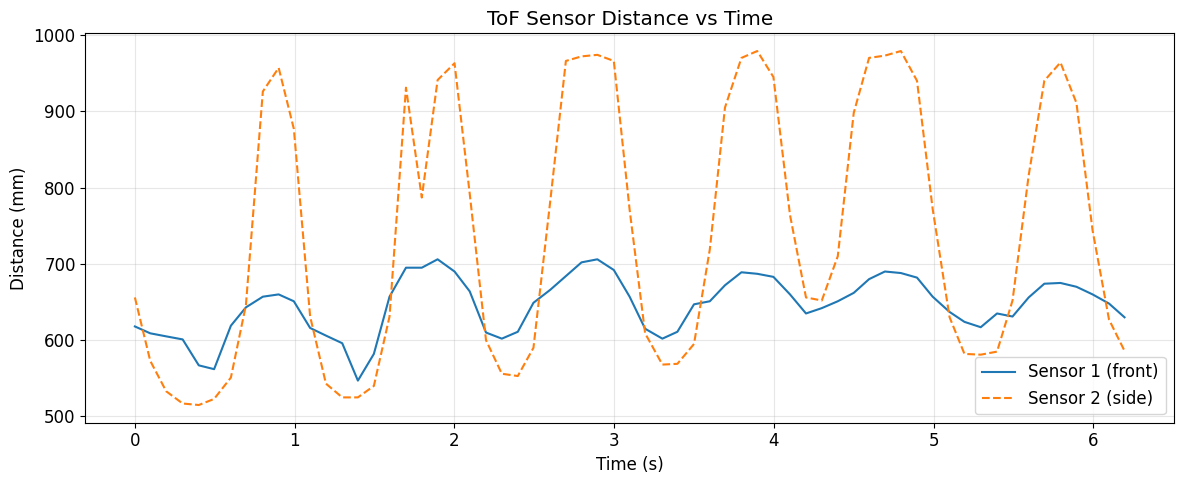

Sensor 1: min=547 mm, max=706 mm


In [19]:
if len(df_tof) < 2:
    print("Not enough ToF data. Re-run Section 8.")
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(df_tof['time_s'], df_tof['dist1'], label='Sensor 1 (front)', linewidth=1.5)

    # Sensor 2 may have -1 for samples where it wasn't ready
    df_tof2 = df_tof[df_tof['dist2'] > 0]
    if len(df_tof2) > 0:
        ax.plot(df_tof2['time_s'], df_tof2['dist2'], label='Sensor 2 (side)',
                linestyle='--', linewidth=1.5)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Distance (mm)')
    ax.set_title('ToF Sensor Distance vs Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('tof_distance_vs_time.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Sensor 1: min={df_tof['dist1'].min()} mm, max={df_tof['dist1'].max()} mm")

---
## 10. Plot: IMU Angle vs Time (Task 12)

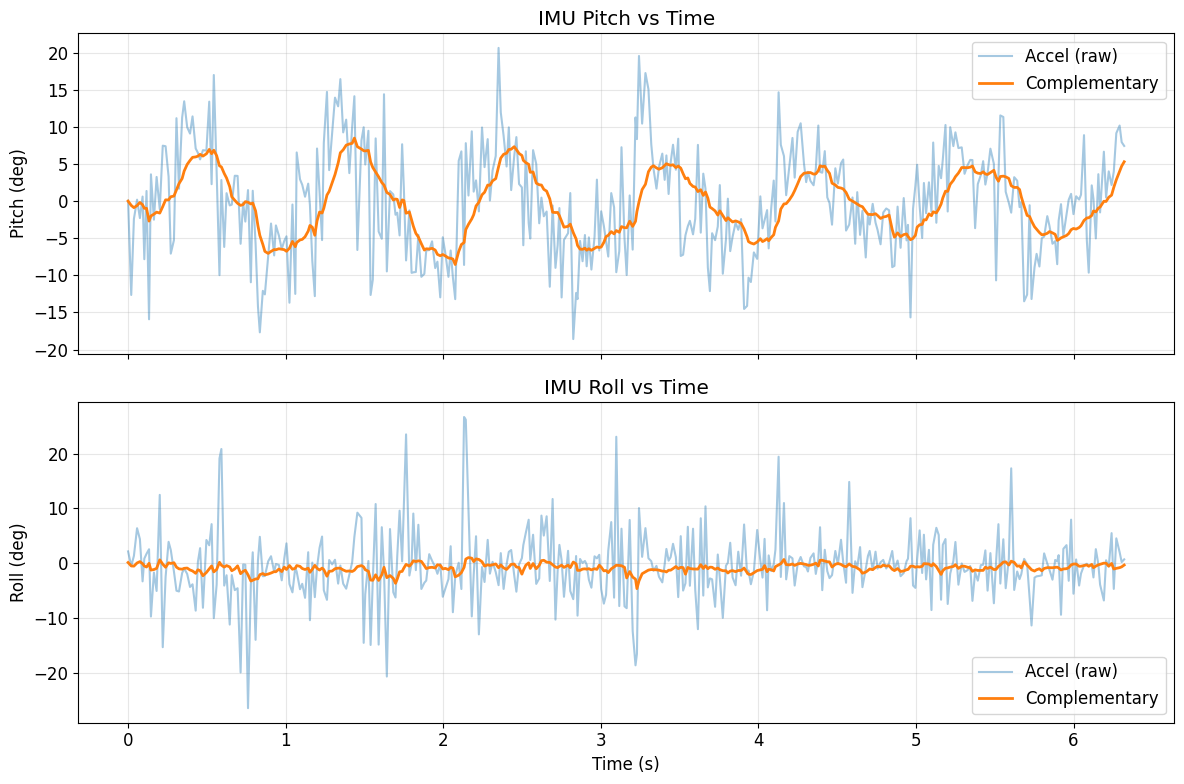

In [20]:
if len(df_imu) < 2:
    print("Not enough IMU data. Re-run Section 8.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Pitch
    axes[0].plot(df_imu['time_s'], df_imu['pitch_a'],    alpha=0.4, label='Accel (raw)')
    axes[0].plot(df_imu['time_s'], df_imu['pitch_comp'],  linewidth=2, label='Complementary')
    axes[0].set_ylabel('Pitch (deg)')
    axes[0].set_title('IMU Pitch vs Time')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Roll
    axes[1].plot(df_imu['time_s'], df_imu['roll_a'],    alpha=0.4, label='Accel (raw)')
    axes[1].plot(df_imu['time_s'], df_imu['roll_comp'],  linewidth=2, label='Complementary')
    axes[1].set_ylabel('Roll (deg)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title('IMU Roll vs Time')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('imu_angle_vs_time.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 11. Save Data

In [21]:
if len(df_tof) > 0:
    df_tof.to_csv('lab3_tof_data.csv', index=False)
    print(f"Saved {len(df_tof)} ToF rows → lab3_tof_data.csv")

if len(df_imu) > 0:
    df_imu.to_csv('lab3_imu_data.csv', index=False)
    print(f"Saved {len(df_imu)} IMU rows → lab3_imu_data.csv")

Saved 63 ToF rows → lab3_tof_data.csv
Saved 388 IMU rows → lab3_imu_data.csv


---
## 12. Combined ToF + IMU Plot

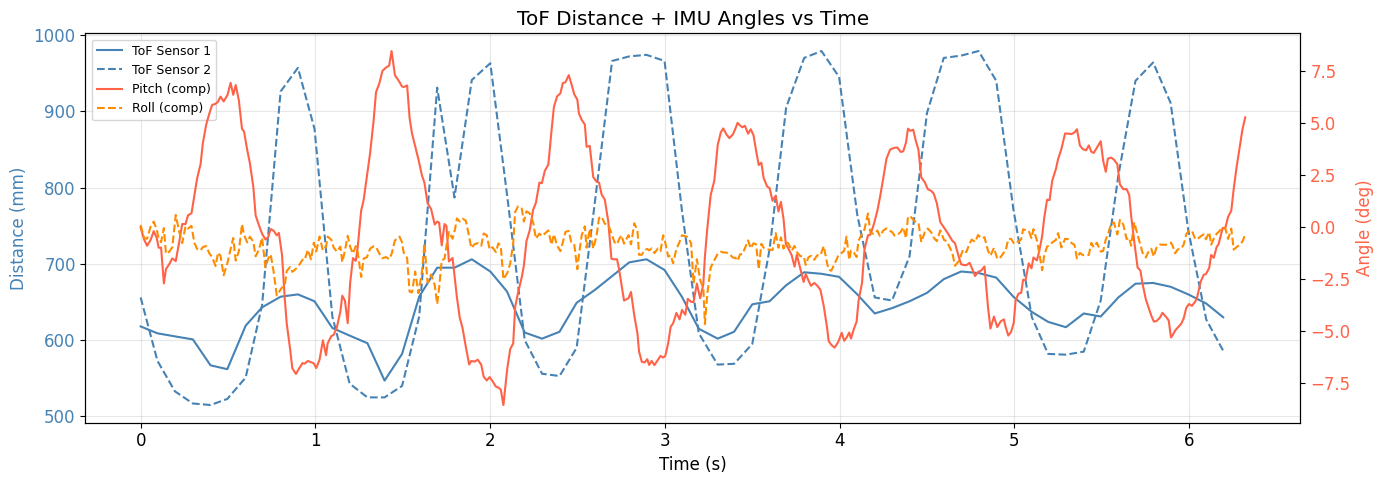

In [23]:
if len(df_tof) < 2 or len(df_imu) < 2:
    print("Not enough data. Re-run Section 8.")
else:
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    # ── Left axis: ToF distance ──────────────────────────────────────────────
    l1, = ax1.plot(df_tof['time_s'], df_tof['dist1'],
                   color='steelblue', linewidth=1.5, label='ToF Sensor 1')
    df_tof2 = df_tof[df_tof['dist2'] > 0]
    if len(df_tof2) > 0:
        l2, = ax1.plot(df_tof2['time_s'], df_tof2['dist2'],
                       color='steelblue', linewidth=1.5, linestyle='--', label='ToF Sensor 2')
    else:
        l2 = None
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Distance (mm)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    # ── Right axis: IMU angles ───────────────────────────────────────────────
    l3, = ax2.plot(df_imu['time_s'], df_imu['pitch_comp'],
                   color='tomato', linewidth=1.5, label='Pitch (comp)')
    l4, = ax2.plot(df_imu['time_s'], df_imu['roll_comp'],
                   color='darkorange', linewidth=1.5, linestyle='--', label='Roll (comp)')
    ax2.set_ylabel('Angle (deg)', color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')

    # ── Legend ───────────────────────────────────────────────────────────────
    handles = [l1] + ([l2] if l2 else []) + [l3, l4]
    ax1.legend(handles=handles, loc='upper left', fontsize=9)

    ax1.set_title('ToF Distance + IMU Angles vs Time')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('tof_imu_combined.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 12. Disconnect

In [ ]:
ble.disconnect()
print("Disconnected from Artemis.")